In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

import transformers
import torch
import tensorflow as tf

from sklearn.model_selection import train_test_split
from transformers import TFBertForSequenceClassification

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer
import pickle

RuntimeError: Failed to import transformers.models.bert.modeling_tf_bert because of the following error (look up to see its traceback):
No module named 'keras.__internal__'

## Importing Dataset

In [3]:
df = pd.read_csv('CyberbullyingDatasets.csv')

## Analysis of data and Preprocessing

In [3]:
df.head()

,S/No,Text,English Meaning,Severe Class
0,1.0,hurl at dissenting voices,hurl at dissenting voices,Mild
1,2.0,leaders are just to selfish,leaders are just to selfish,Mild
2,3.0,they call nigeria a zoo,they call nigeria a zoo,Mild
3,4.0,make baseless assumptions and conclusions,make baseless assumptions and conclusions,Mild
4,5.0,haters picked it,haters picked it,Mild


In [4]:
df.shape

(3712, 4)

## Handling Null Values

In [5]:
df.isnull().sum()

S/No                5
Text                5
English Meaning    12
Severe Class        5
dtype: int64

In [4]:
df=df.dropna()

In [7]:
df.isnull().sum()

S/No               0
Text               0
English Meaning    0
Severe Class       0
dtype: int64

## Handling Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

## Distribution of Dataset

In [9]:
df['Severe Class'].value_counts()

Severe Class
Moderate       1278
Severe         1253
Mild           1083
Very Severe      86
Name: count, dtype: int64

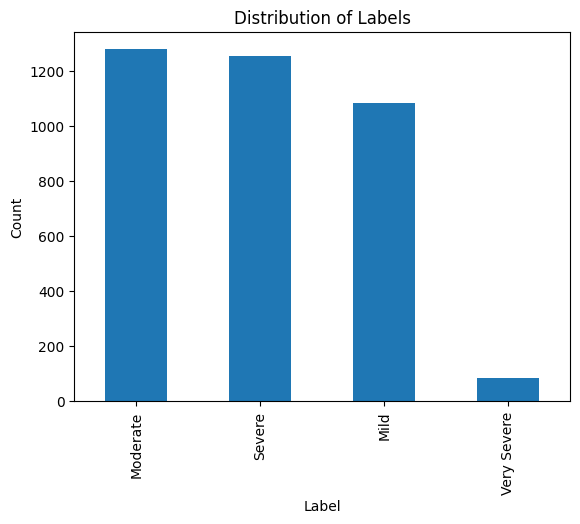

In [10]:
df['Severe Class'].value_counts().plot(kind='bar')
plt.xlabel('Label') 
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

## Merging classes

In [5]:
def merge_classes(label):
    if label == "Mild":
        return "Mild"
    elif label == "Moderate":
        return "Moderate"
    elif label in ["Severe", "Very Severe"]:
        return "High Risk"

df["Severe Class"] = df["Severe Class"].apply(merge_classes)

In [13]:
print(df["Severe Class"].value_counts())

Severe Class
High Risk    1339
Moderate     1278
Mild         1083
Name: count, dtype: int64


## Separation of dependent and independent variables

In [6]:
x = df['Text']
y = df['Severe Class']

 ## Encoding

In [7]:
le = LabelEncoder()
y = le.fit_transform(y)

## Train Test Splitting

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42,stratify=y)

## Tokenizer

In [9]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AmnaAli\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode,

In [10]:
def encode(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="np"
    )

In [11]:
train_enc = encode(x_train)
test_enc = encode(x_test)

## Load BERT model

In [ ]:
model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

ImportError: 
BertForSequenceClassification requires the PyTorch library but it was not found in your environment.
However, we were able to find a TensorFlow installation. TensorFlow classes begin
with "TF", but are otherwise identically named to our PyTorch classes. This
means that the TF equivalent of the class you tried to import would be "TFBertForSequenceClassification".
If you want to use TensorFlow, please use TF classes instead!

If you really do want to use PyTorch please go to
https://pytorch.org/get-started/locally/ and follow the instructions that
match your environment.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

2.11.0+cpu
False


In [ ]:
model.fit(
    {
        "input_ids": train_enc["input_ids"],
        "attention_mask": train_enc["attention_mask"]
    },
    y_train,
    validation_split=0.1,
    epochs=2,
    batch_size=16
)

In [ ]:
loss, acc = model.evaluate(
    {
        "input_ids": test_enc["input_ids"],
        "attention_mask": test_enc["attention_mask"]
    },
    y_test
)

print("Accuracy:", acc)

In [ ]:
model.save_pretrained("chat_severity_model")
tokenizer.save_pretrained("chat_severity_tokenizer_model")

import pickle
with open("chat_severity_encoder.pkl", "wb") as f:
    pickle.dump(le, f)